<a href="https://colab.research.google.com/github/contreras-juan/Material-Ciencia-de-Datos/blob/main/Deep_Learning/Ejercicios/Soluciones/02_Taller_Convoluciones_y_CNN_Solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<h1 style="color: #FECB05; text-align: center;">Solución — Taller práctico: Convoluciones y CNN</h1>


<h2 style="color: #007ACC;">Autores</h2>

- [Juan Felipe Contreras Alcívar](https://www.linkedin.com/in/juanf-contreras/)

> Solución de referencia del taller [`02_Taller_Convoluciones_y_CNN.ipynb`](../02_Taller_Convoluciones_y_CNN.ipynb).
> Los resultados numéricos pueden variar ligeramente según versión de TensorFlow/hardware.


---


<h2 style="color: #007ACC;">Tabla de contenido</h2>

- [Instalación e importaciones](#importaciones)
- [Ejercicio 1. Convolución 1D](#ejercicio-1)
- [Ejercicio 2. Convolución 2D y tamaño de salida](#ejercicio-2)
- [Ejercicio 3. Filtros sobre imágenes](#ejercicio-3)
- [Ejercicio 4. Padding, stride y pooling](#ejercicio-4)
- [Ejercicio 5. Parámetros de una capa Conv2D](#ejercicio-5)
- [Ejercicio 6. CNN para clasificar dígitos](#ejercicio-6)
- [Ejercicio 7. Regularización y aumentación](#ejercicio-7)
- [Ejercicio integrador](#ejercicio-integrador)


---

<a id="importaciones"></a>
<h2 style="color: #007ACC;">Instalación e importaciones</h2>


In [1]:
# Instalación de librerías necesarias para esta sesión
# (útil en Google Colab o en un entorno nuevo)
%pip install -q numpy pandas matplotlib scipy Pillow scikit-learn tensorflow

/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

from scipy.signal import convolve2d

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import L2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

I0000 00:00:1786206200.937485   47975 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786206200.937778   47975 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786206200.959281   47975 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0


I0000 00:00:1786206201.572023   47975 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786206201.572178   47975 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---

<a id="ejercicio-1"></a>
<h2 style="color: #007ACC;">Ejercicio 1. Convolución 1D</h2>


In [3]:
f = np.array([1, 2, 3, 4])
g = np.array([1, 0, -1])

full = np.convolve(f, g, mode="full")
print("f * g (full) =", full)
print("Longitud esperada:", len(f) + len(g) - 1)

# Interpretación: g = [1, 0, -1] actúa como un detector de diferencias/bordes 1D
# (aproxima una derivada discreta / contraste local).

f * g (full) = [ 1  2  2  2 -3 -4]
Longitud esperada: 6


Suma de probabilidades: 1.0
P(suma=2) = 0.0278
P(suma=3) = 0.0556
P(suma=4) = 0.0833
P(suma=5) = 0.1111
P(suma=6) = 0.1389
P(suma=7) = 0.1667
P(suma=8) = 0.1389
P(suma=9) = 0.1111
P(suma=10) = 0.0833
P(suma=11) = 0.0556
P(suma=12) = 0.0278


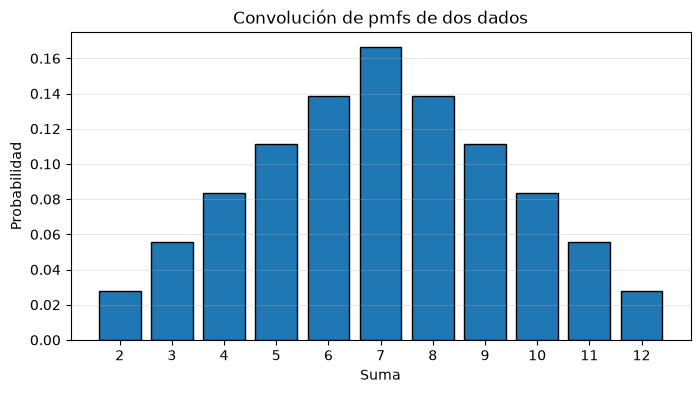

In [4]:
p = np.ones(6) / 6.0
C = np.convolve(p, p, mode="full")
sumas = np.arange(2, 13)

print("Suma de probabilidades:", C.sum())
for s, c in zip(sumas, C):
    print(f"P(suma={s}) = {c:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(sumas, C, edgecolor="black")
plt.xlabel("Suma")
plt.ylabel("Probabilidad")
plt.title("Convolución de pmfs de dos dados")
plt.xticks(sumas)
plt.grid(axis="y", alpha=0.3)
plt.show()

---

<a id="ejercicio-2"></a>
<h2 style="color: #007ACC;">Ejercicio 2. Convolución 2D y tamaño de salida</h2>


In [5]:
X = np.array([
    [1, 2, 3, 0],
    [0, 1, 2, 3],
    [3, 0, 1, 2],
    [2, 3, 0, 1],
], dtype=float)

K = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=float)

valid = convolve2d(X, K, mode="valid")
same = convolve2d(X, K, mode="same")
print("valid shape:", valid.shape, "\n", valid)
print("same shape:", same.shape, "\n", same)

H_in, F, S = 4, 3, 1
H_out_p0 = (H_in - F + 2 * 0) // S + 1
H_out_p1 = (H_in - F + 2 * 1) // S + 1
print("H_out (P=0):", H_out_p0)
print("H_out (P=1):", H_out_p1)

valid shape: (2, 2) 
 [[ 2.  2.]
 [-2.  2.]]
same shape: (4, 4) 
 [[ 3.  4.  0. -5.]
 [ 3.  2.  2. -6.]
 [ 4. -2.  2. -3.]
 [ 3. -4.  0. -1.]]
H_out (P=0): 2
H_out (P=1): 4


**Respuesta:** en Keras, `Conv2D` implementa en la práctica **correlación cruzada** (el kernel no se voltea como en la convolución matemática de SciPy). Como los pesos se aprenden, esa diferencia se absorbe durante el entrenamiento.


---

<a id="ejercicio-3"></a>
<h2 style="color: #007ACC;">Ejercicio 3. Filtros sobre imágenes</h2>


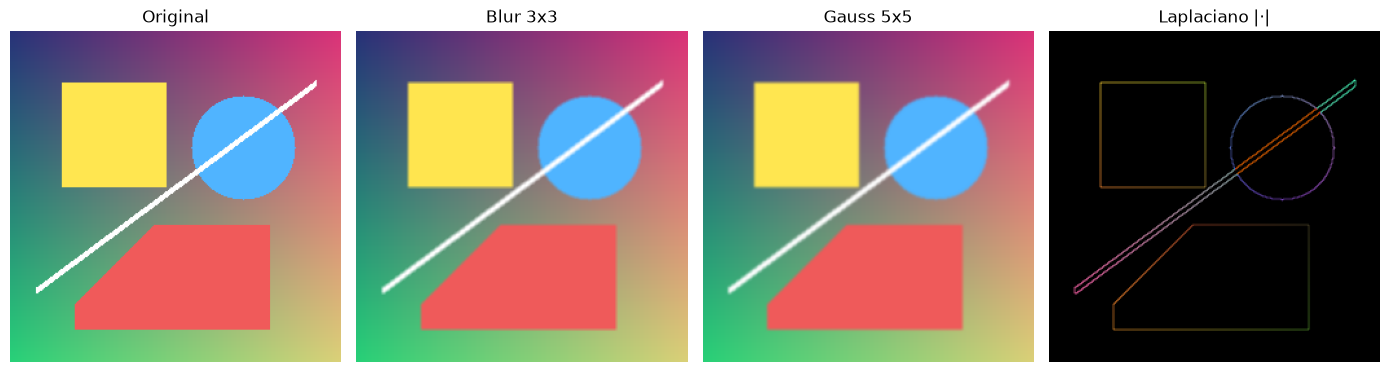

In [6]:
def gen_gaussian_kernel(N, sigma):
    if N % 2 == 0:
        raise ValueError("N debe ser impar")
    half = N // 2
    r = np.arange(-half, half + 1)
    x, y = np.meshgrid(r, r)
    k = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return k / k.sum()


def aplicar_kernel(img, kernel):
    arr = np.array(img.convert("RGB")) if isinstance(img, Image.Image) else np.asarray(img)
    if kernel.ndim == 2:
        kernel = np.stack([kernel, kernel, kernel], axis=-1)
    outs = []
    for c in range(3):
        outs.append(
            convolve2d(arr[:, :, c].astype(float), kernel[:, :, c], mode="same", boundary="symm")
        )
    return arr, np.stack(outs, axis=2)


def to_uint8(arr):
    a = np.asarray(arr, dtype=float)
    a = a - a.min()
    if a.max() > 0:
        a = a / a.max()
    return (a * 255).astype(np.uint8)


candidatas = [
    Path("../img/demo_convoluciones.png"),
    Path("../../img/demo_convoluciones.png"),
]
ruta = next((p for p in candidatas if p.exists()), None)
if ruta is None:
    yy, xx = np.mgrid[0:128, 0:128]
    synth = np.stack([
        (xx).astype(np.uint8),
        (yy).astype(np.uint8),
        np.full_like(xx, 120, dtype=np.uint8),
    ], axis=-1)
    imagen = Image.fromarray(synth)
else:
    imagen = Image.open(ruta).convert("RGB")

orig, blur = aplicar_kernel(imagen, np.ones((3, 3)) / 9)
_, gauss = aplicar_kernel(imagen, gen_gaussian_kernel(5, 1.0))
_, lap = aplicar_kernel(imagen, np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], float))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ["Original", "Blur 3x3", "Gauss 5x5", "Laplaciano |·|"]
imgs = [orig, np.clip(blur, 0, 255).astype(np.uint8), np.clip(gauss, 0, 255).astype(np.uint8), to_uint8(np.abs(lap))]
for ax, im, t in zip(axes, imgs, titles):
    ax.imshow(im)
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()

---

<a id="ejercicio-4"></a>
<h2 style="color: #007ACC;">Ejercicio 4. Padding, stride y pooling</h2>


In [7]:
def pool2d(x, size=2, stride=2, mode="max"):
    x = np.asarray(x, dtype=float)
    h, w = x.shape
    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            ventana = x[i * stride:i * stride + size, j * stride:j * stride + size]
            out[i, j] = np.max(ventana) if mode == "max" else np.mean(ventana)
    return out


def conv2d_stride(x, kernel, stride=1):
    x = np.asarray(x, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    k_rot = np.rot90(kernel, 2)
    kh, kw = kernel.shape
    h, w = x.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            ventana = x[i * stride:i * stride + kh, j * stride:j * stride + kw]
            out[i, j] = np.sum(ventana * k_rot)
    return out


M = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 8, 3, 0],
    [2, 1, 9, 5],
], dtype=float)

k_avg = np.ones((2, 2)) / 4
print("Max pool:", pool2d(M, 2, 2, "max"), "shape=", pool2d(M, 2, 2, "max").shape)
print("Avg pool:", pool2d(M, 2, 2, "avg"), "shape=", pool2d(M, 2, 2, "avg").shape)
print("Conv stride 2:", np.round(conv2d_stride(M, k_avg, 2), 2), "shape=", conv2d_stride(M, k_avg, 2).shape)
print("Preferimos pooling cuando queremos reducir espacialmente sin añadir muchos parámetros aprendibles.")

Max pool: [[6. 4.]
 [8. 9.]] shape= (2, 2)
Avg pool: [[3.75 2.25]
 [4.5  4.25]] shape= (2, 2)
Conv stride 2: [[3.75 2.25]
 [4.5  4.25]] shape= (2, 2)
Preferimos pooling cuando queremos reducir espacialmente sin añadir muchos parámetros aprendibles.


---

<a id="ejercicio-5"></a>
<h2 style="color: #007ACC;">Ejercicio 5. Parámetros de una capa Conv2D</h2>


In [8]:
# Cálculo manual
params_1 = (3**2 * 3 + 1) * 32
params_2 = (3**2 * 32 + 1) * 64
print("Conv2D(32,3) sobre RGB:", params_1)
print("Conv2D(64,3) sobre 32 canales:", params_2)

tf.random.set_seed(SEED)
model_params = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation="relu"),
])
model_params.summary()
print("Params capa 0:", model_params.layers[0].count_params())
print("Params capa 1:", model_params.layers[1].count_params())

Conv2D(32,3) sobre RGB: 896
Conv2D(64,3) sobre 32 canales: 18496


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1786206202.054487   47975 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786206202.054756   48076 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786206202.076274   47975 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are ins

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

Params capa 0: 896
Params capa 1: 18496


---

<a id="ejercicio-6"></a>
<h2 style="color: #007ACC;">Ejercicio 6. CNN para clasificar dígitos</h2>


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 0.9611


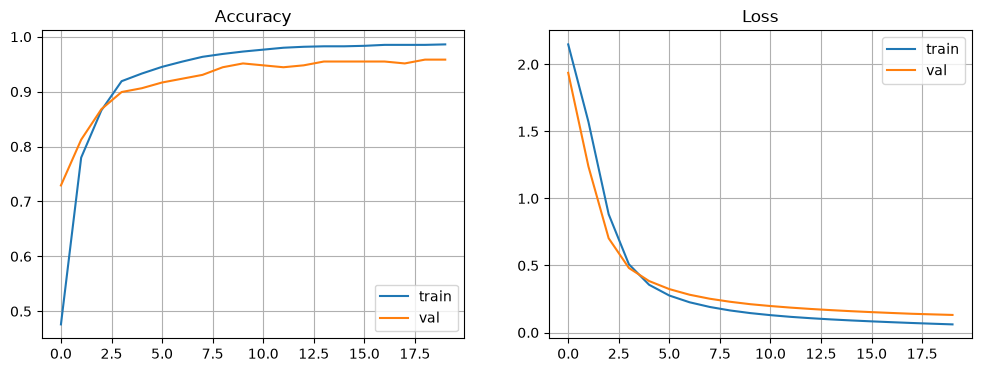

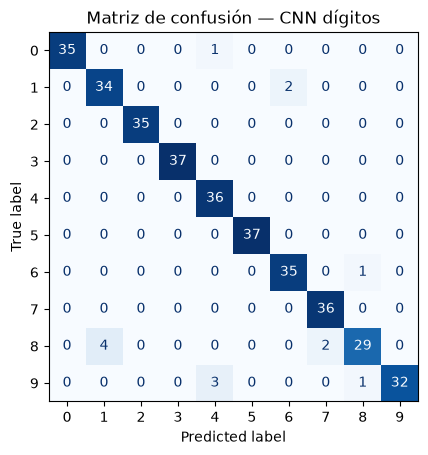

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.94      0.92        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.90      1.00      0.95        36
           5       1.00      1.00      1.00        37
           6       0.95      0.97      0.96        36
           7       0.95      1.00      0.97        36
           8       0.94      0.83      0.88        35
           9       1.00      0.89      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



In [9]:
digits = load_digits()
X = digits.images.astype("float32") / 16.0
X = X.reshape(-1, 8, 8, 1)
y = to_categorical(digits.target, 10)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=digits.target
)

tf.random.set_seed(SEED)
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])
model_cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=0,
)

test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn.history["accuracy"], label="train")
axes[0].plot(history_cnn.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_cnn.history["loss"], label="train")
axes[1].plot(history_cnn.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend(); axes[1].grid(True)
plt.show()

y_pred = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusión — CNN dígitos")
plt.show()
print(classification_report(y_true, y_pred))

---

<a id="ejercicio-7"></a>
<h2 style="color: #007ACC;">Ejercicio 7. Regularización y aumentación</h2>


In [10]:
# Reutilizamos arrays del ejercicio 6 (X_train/X_test ya en [0,1])
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)

train_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
val_gen = ImageDataGenerator()  # sin augmentación

flow_tr = train_gen.flow(X_tr, y_tr, batch_size=32, seed=SEED)
flow_val = val_gen.flow(X_val, y_val, batch_size=32, shuffle=False)

tf.random.set_seed(SEED)
model_reg = Sequential([
    Conv2D(32, (3, 3), padding="same", input_shape=(8, 8, 1), kernel_regularizer=L2(1e-4)),
    BatchNormalization(),
    tf.keras.layers.ReLU(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),
    Dense(10, activation="softmax"),
])
model_reg.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=0),
]

history_reg = model_reg.fit(
    flow_tr,
    validation_data=flow_val,
    epochs=40,
    callbacks=callbacks,
    verbose=0,
)

loss_r, acc_r = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"CNN regularizada — test acc: {acc_r:.4f} | épocas efectivas: {len(history_reg.history['loss'])}")
print(f"CNN básica (ej. 6) — test acc: {test_acc:.4f}")

/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1786206203.976472   47975 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


CNN regularizada — test acc: 0.9861 | épocas efectivas: 40
CNN básica (ej. 6) — test acc: 0.9611


---

<a id="ejercicio-integrador"></a>
<h2 style="color: #007ACC;">Ejercicio integrador</h2>


In [11]:
# MLP sobre vectores 64-D
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

tf.random.set_seed(SEED)
model_mlp = Sequential([
    Dense(128, activation="relu", input_shape=(64,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])
model_mlp.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
hist_mlp = model_mlp.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[es],
    verbose=0,
)
loss_mlp, acc_mlp = model_mlp.evaluate(X_test_flat, y_test, verbose=0)

# CNN (reentrenada de forma comparable)
tf.random.set_seed(SEED)
model_cnn2 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])
model_cnn2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
hist_cnn2 = model_cnn2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[es],
    verbose=0,
)
loss_cnn2, acc_cnn2 = model_cnn2.evaluate(X_test, y_test, verbose=0)

resumen = pd.DataFrame([
    {
        "modelo": "MLP",
        "test_acc": round(acc_mlp, 4),
        "params": model_mlp.count_params(),
        "epochs": len(hist_mlp.history["loss"]),
    },
    {
        "modelo": "CNN",
        "test_acc": round(acc_cnn2, 4),
        "params": model_cnn2.count_params(),
        "epochs": len(hist_cnn2.history["loss"]),
    },
])
print(resumen.to_string(index=False))
print(
    "\nConclusión: la CNN suele aprovechar la estructura espacial local (bordes/trazos del dígito) "
    "con menos o mejores parámetros efectivos para imágenes, mientras el MLP trata cada píxel de forma "
    "más independiente tras el aplanado."
)

/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


modelo  test_acc  params  epochs
   MLP    0.9639   17226      31
   CNN    0.9667   19466      40

Conclusión: la CNN suele aprovechar la estructura espacial local (bordes/trazos del dígito) con menos o mejores parámetros efectivos para imágenes, mientras el MLP trata cada píxel de forma más independiente tras el aplanado.
